In [2]:
import pandas as pd

df = pd.read_csv("resumes.csv")

df['Selected'] = df['Skills'].apply(lambda x: 1 if 'Python' in x else 0)

In [8]:
import random

for i in random.sample(range(len(df)), int(0.2 * len(df))):
    df.loc[i, 'Selected'] = 1 - df.loc[i, 'Selected']

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Skills'])
y = df['Selected']

print("Shape of X:", X.shape)

Shape of X: (500, 26)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (400, 26)
Test: (100, 26)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.82


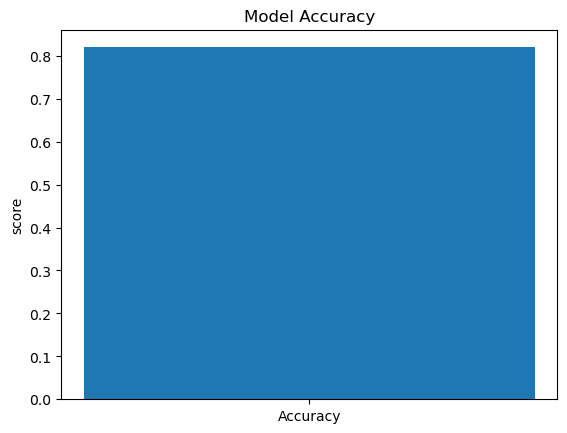

In [15]:
import matplotlib.pyplot as plt

plt.bar(['Accuracy'], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("score")
plt.show()

Accuracy: 0.82


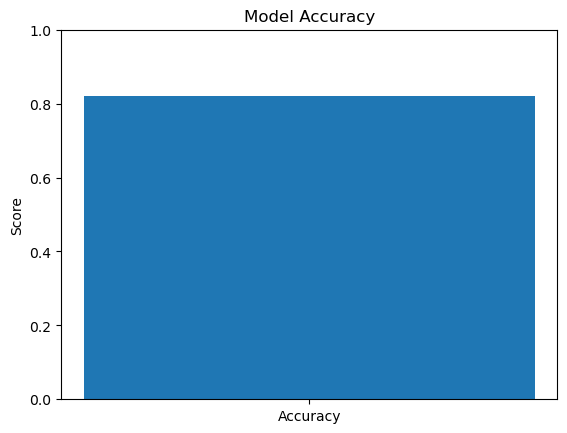

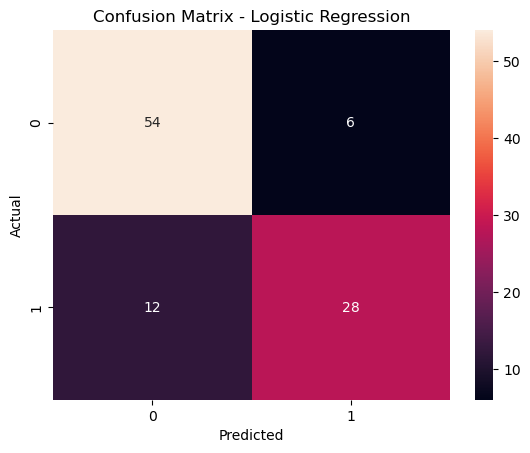

In [18]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Accuracy Chart
import matplotlib.pyplot as plt

plt.bar(['Accuracy'], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()